Barella location calculation by regression.

let p be a point on the xy plane, (-s,0) the location of the source and (d,t) the coordinates of line passing trough (-s,0) and p. the vertical line that passes trough (d,0) is the detector line.

let θ be the angle of rotation of p around the center (s and d are not affected by the rotation) 

given a set of θ_i and t_i I want to find the unrotated p. 

the basic equation is:
$$ t((p_θ)_x + s) = (p_θ)_y(d+s)$$
with p_θ = R(θ)p and R the basic rotation matrix

it is possible to rearrange the equation in the form Ax=y and find x with linear regression:
A_i = (t_i, -(d+s))R(θ_i)
y_i = -t_i s
x = (p_x, p_y)


In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARAMS_FILE = "maria_cristeta.json"
SCAN_INDEX = 0  # imgScan_0

In [21]:
# Load scan parameters
with open(PARAMS_FILE) as f:
    params = json.load(f)

scan = params["scans"][SCAN_INDEX]

angles_deg = np.array(scan["angle_eff"])          # degrees
angles_rad = np.deg2rad(angles_deg)
sod = np.array(scan["sod"])                        # source-to-isocenter distance (mm)
sid = np.array(scan["sid"])                        # source-to-detector distance (mm)
det_col_pitch = scan["det_column_pitch"]           # mm per pixel

n_proj = len(angles_rad)
print(f"Projections: {n_proj}")
print(f"Detector column pitch: {det_col_pitch:.4f} mm")
print(f"SOD mean: {sod.mean():.2f} mm  SID mean: {sid.mean():.2f} mm")

Projections: 480
Detector column pitch: 0.3080 mm
SOD mean: 579.32 mm  SID mean: 986.87 mm


In [22]:
# Load measurements from CSV
# Rows with empty x_pixel or label are skipped automatically.

TABLE_FILE = "stretcher_measurements.csv"

table = pd.read_csv(TABLE_FILE)
table = table.dropna(subset=["x_pixel", "label"])
table["projection_index"] = table["projection_index"].astype(int)

labels = table["label"].unique()
print(f"Loaded {len(table)} measurements — labels: {list(labels)}")
print(table.head(10))

Loaded 173 measurements — labels: ['A', 'B']
   projection_index  angle_deg  x_pixel label
0                25    18.9795  136.000     A
1                45    33.9742   95.500     A
2                46    34.7248  107.500     A
3                47    35.4755  119.500     A
4                48    36.2262  133.500     A
5                49    36.9769  146.167     A
6                50    37.7276  160.167     A
7                51    38.4784  173.500     A
8                52    39.2292  186.167     A
9                53    39.9800  198.833     A


In [23]:
# Linear regression per label
def fit_position(subset):
    rows_A, rows_y = [], []
    for _, row in subset.iterrows():
        i  = int(row["projection_index"])
        th = angles_rad[i]
        s  = sod[i]
        d  = sid[i] - sod[i]
        t  = row["x_pixel"] * det_col_pitch  # mm
        R  = np.array([[np.cos(th), -np.sin(th)],
                       [np.sin(th),  np.cos(th)]])
        rows_A.append(np.array([t, -(d + s)]) @ R)
        rows_y.append(-t * s)
    A = np.array(rows_A)
    y = np.array(rows_y)
    x_hat, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return x_hat, A, y

results = {}
for label, subset in table.groupby("label"):
    x_hat, A, y = fit_position(subset)
    results[label] = {"x_hat": x_hat, "A": A, "y": y, "subset": subset}
    print(f"[{label}]  px = {x_hat[0]:.3f} mm,  py = {x_hat[1]:.3f} mm  ({len(subset)} points)")

[A]  px = 221.108 mm,  py = -149.633 mm  (79 points)
[B]  px = 83.806 mm,  py = 240.595 mm  (94 points)


Average stretcher position:  px = 152.457 mm,  py = 45.481 mm


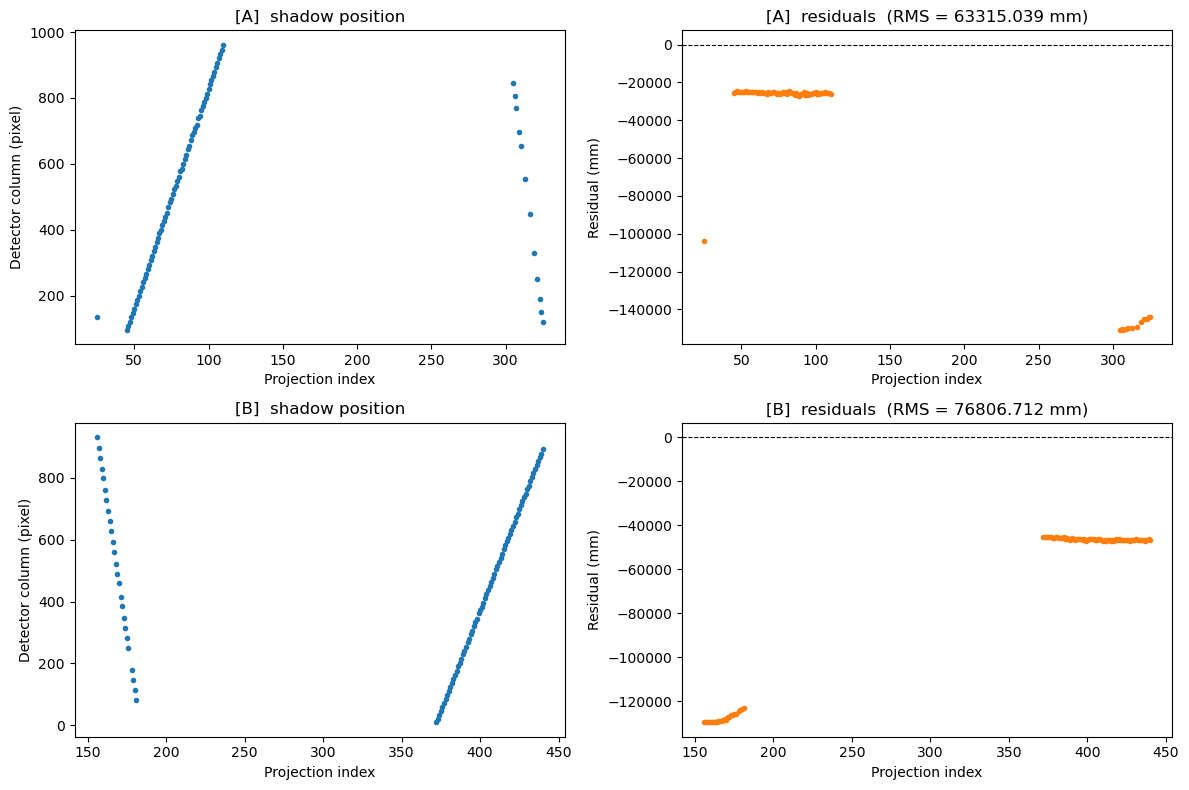

In [24]:
# Average position and residual plots
positions = np.array([r["x_hat"] for r in results.values()])
avg = positions.mean(axis=0)
print(f"Average stretcher position:  px = {avg[0]:.3f} mm,  py = {avg[1]:.3f} mm")

fig, axes = plt.subplots(len(results), 2, figsize=(12, 4 * len(results)), squeeze=False)

for ax_row, (label, r) in zip(axes, results.items()):
    y_pred = r["A"] @ r["x_hat"]
    res = r["y"] - y_pred
    idx = r["subset"]["projection_index"]

    ax_row[0].plot(idx, r["subset"]["x_pixel"], "o", ms=3)
    ax_row[0].set_xlabel("Projection index")
    ax_row[0].set_ylabel("Detector column (pixel)")
    ax_row[0].set_title(f"[{label}]  shadow position")

    ax_row[1].plot(idx, res, "o", ms=3, color="C1")
    ax_row[1].axhline(0, color="k", lw=0.8, ls="--")
    ax_row[1].set_xlabel("Projection index")
    ax_row[1].set_ylabel("Residual (mm)")
    rms = np.sqrt(np.mean(res**2))
    ax_row[1].set_title(f"[{label}]  residuals  (RMS = {rms:.3f} mm)")

plt.tight_layout()
plt.show()